<a href="https://colab.research.google.com/github/dalkhaseeb-D/at-risk-student-prediction/blob/main/notebooks/01_data_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import zipfile
import requests
from pathlib import Path

DATA_DIR = Path("/content/oulad_project/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

url = "https://archive.ics.uci.edu/static/public/349/open%2Buniversity%2Blearning%2Banalytics%2Bdataset.zip"
zip_path = DATA_DIR / "oulad.zip"

response = requests.get(url)
response.raise_for_status()
zip_path.write_bytes(response.content)

with zipfile.ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall(DATA_DIR)

print("OULAD dataset downloaded and extracted successfully.")
print(os.listdir(DATA_DIR))

OULAD dataset downloaded and extracted successfully.
['oulad.zip', 'studentRegistration.csv', 'OULAD.names', 'vle.csv', 'studentVle.csv', 'studentAssessment.csv', 'assessments.csv', 'courses.csv', 'studentInfo.csv']


In [4]:
import pandas as pd

small_files = [
    "courses.csv",
    "assessments.csv",
    "studentInfo.csv",
    "studentRegistration.csv",
    "studentAssessment.csv",
    "vle.csv"
]

tables = {}

for file in small_files:
    file_path = DATA_DIR / file
    tables[file] = pd.read_csv(file_path)
    print(f"{file}: {tables[file].shape[0]} rows, {tables[file].shape[1]} columns")

courses.csv: 22 rows, 3 columns
assessments.csv: 206 rows, 6 columns
studentInfo.csv: 32593 rows, 12 columns
studentRegistration.csv: 32593 rows, 5 columns
studentAssessment.csv: 173912 rows, 5 columns
vle.csv: 6364 rows, 6 columns


In [6]:
audit_results = []

for file, dataframe in tables.items():
    audit_results.append({
        "File": file,
        "Rows": dataframe.shape[0],
        "Columns": dataframe.shape[1],
        "Duplicate_Rows": dataframe.duplicated().sum(),
        "Missing_Values": dataframe.isna().sum().sum()
    })

audit_df = pd.DataFrame(audit_results)
display(audit_df)

print("\nStudent final-result distribution:")
display(tables["studentInfo.csv"]["final_result"].value_counts())

,File,Rows,Columns,Duplicate_Rows,Missing_Values
0,courses.csv,22,3,0,0
1,assessments.csv,206,6,0,0
2,studentInfo.csv,32593,12,0,0
3,studentRegistration.csv,32593,5,0,0
4,studentAssessment.csv,173912,5,0,0
5,vle.csv,6364,6,0,0



Student final-result distribution:


,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


In [10]:
student_info = tables["studentInfo.csv"]
registration = tables["studentRegistration.csv"]

keys = ["code_module", "code_presentation", "id_student"]

student_data = student_info.merge(
    registration,
    on=keys,
    how="left"
)

cutoff_day = 28

eligible_students = student_data[
    student_data["date_unregistration"].isna() |
    (student_data["date_unregistration"] > cutoff_day)
].copy()

eligible_students["target_at_risk"] = eligible_students[
    "final_result"
].isin(["Fail", "Withdrawn"]).astype(int)

print("Original registrations:", len(student_data))
print("Eligible at day 28:", len(eligible_students))
print(
    eligible_students["target_at_risk"]
    .value_counts()
    .rename(index={0: "Successful", 1: "At Risk"})
)

TypeError: '>' not supported between instances of 'str' and 'int'

In [12]:
student_data["date_unregistration"] = pd.to_numeric(
    student_data["date_unregistration"],
    errors="coerce"
)

cutoff_day = 28

eligible_students = student_data[
    student_data["date_unregistration"].isna() |
    (student_data["date_unregistration"] > cutoff_day)
].copy()

eligible_students["target_at_risk"] = (
    eligible_students["final_result"]
    .isin(["Fail", "Withdrawn"])
    .astype(int)
)

print("Original registrations:", len(student_data))
print("Eligible at day 28:", len(eligible_students))
print("\nTarget distribution:")
print(
    eligible_students["target_at_risk"]
    .value_counts()
    .rename(index={0: "Successful", 1: "At Risk"})
)

Original registrations: 32593
Eligible at day 28: 27538

Target distribution:
target_at_risk
Successful    15385
At Risk       12153
Name: count, dtype: int64


In [13]:
%pip -q install duckdb

import duckdb

vle_path = str(DATA_DIR / "studentVle.csv")

engagement = duckdb.sql(f"""
    SELECT
        code_module,
        code_presentation,
        id_student,
        SUM(sum_click) AS total_clicks_wk1_4,
        COUNT(*) AS interaction_records_wk1_4,
        COUNT(DISTINCT date) AS active_days_wk1_4,
        COUNT(DISTINCT id_site) AS unique_sites_wk1_4
    FROM read_csv_auto('{vle_path}')
    WHERE date BETWEEN 0 AND 27
    GROUP BY code_module, code_presentation, id_student
""").df()

print("Students with early VLE activity:", len(engagement))
display(engagement.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Students with early VLE activity: 27886


,code_module,code_presentation,id_student,total_clicks_wk1_4,interaction_records_wk1_4,active_days_wk1_4,unique_sites_wk1_4
0,AAA,2014J,2522927,818.0,238,28,25
1,AAA,2014J,2473538,427.0,123,11,36
2,AAA,2014J,2436812,173.0,59,14,18
3,AAA,2014J,1398979,1273.0,298,28,37
4,AAA,2014J,1609002,268.0,89,15,21


In [14]:
engagement_features = [
    "total_clicks_wk1_4",
    "interaction_records_wk1_4",
    "active_days_wk1_4",
    "unique_sites_wk1_4"
]

model_data = eligible_students.merge(
    engagement,
    on=["code_module", "code_presentation", "id_student"],
    how="left",
    validate="one_to_one"
)

model_data[engagement_features] = (
    model_data[engagement_features].fillna(0)
)

print("Final student records:", len(model_data))
print(
    "Students with no VLE activity:",
    (model_data["total_clicks_wk1_4"] == 0).sum()
)

print("\nAverage engagement by outcome:")
display(
    model_data.groupby("target_at_risk")[engagement_features]
    .mean()
    .rename(index={0: "Successful", 1: "At Risk"})
    .round(2)
)

Final student records: 27538
Students with no VLE activity: 1246

Average engagement by outcome:


,total_clicks_wk1_4,interaction_records_wk1_4,active_days_wk1_4,unique_sites_wk1_4
target_at_risk,,,,
Successful,338.79,89.38,12.49,26.19
At Risk,196.76,56.31,8.33,19.47


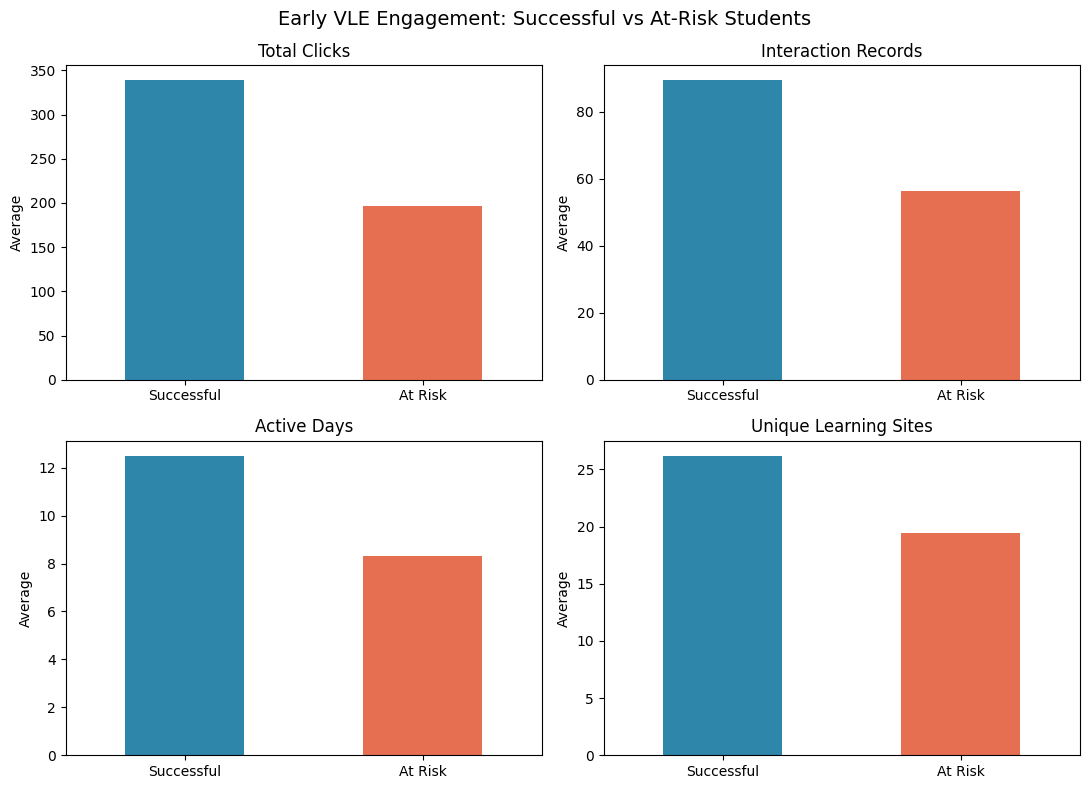

In [15]:
import matplotlib.pyplot as plt

engagement_summary = (
    model_data.groupby("target_at_risk")[engagement_features]
    .mean()
    .rename(index={0: "Successful", 1: "At Risk"})
)

titles = [
    "Total Clicks",
    "Interaction Records",
    "Active Days",
    "Unique Learning Sites"
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for feature, title, axis in zip(
    engagement_features, titles, axes.flatten()
):
    engagement_summary[feature].plot(
        kind="bar",
        ax=axis,
        color=["#2E86AB", "#E76F51"]
    )
    axis.set_title(title)
    axis.set_xlabel("")
    axis.set_ylabel("Average")
    axis.tick_params(axis="x", rotation=0)

plt.suptitle(
    "Early VLE Engagement: Successful vs At-Risk Students",
    fontsize=14
)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

categorical_features = [
    "code_module",
    "code_presentation",
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability"
]

numeric_features = [
    "num_of_prev_attempts",
    "studied_credits",
    "total_clicks_wk1_4",
    "interaction_records_wk1_4",
    "active_days_wk1_4",
    "unique_sites_wk1_4"
]

X = model_data[categorical_features + numeric_features]
y = model_data["target_at_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_features),
    ("numeric", numeric_pipeline, numeric_features)
])

print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Training at-risk percentage:", round(y_train.mean() * 100, 2))
print("Testing at-risk percentage:", round(y_test.mean() * 100, 2))

Training records: 22030
Testing records: 5508
Training at-risk percentage: 44.13
Testing at-risk percentage: 44.14


In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent"
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.08,
        max_leaf_nodes=31,
        class_weight="balanced",
        random_state=42
    )
}

results = []
fitted_models = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test, predictions
        ),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_test, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

    fitted_models[model_name] = pipeline
    print(model_name, "completed")

model_results = (
    pd.DataFrame(results)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(model_results.round(3))

Dummy Baseline completed
Logistic Regression completed
Decision Tree completed
Random Forest completed
Gradient Boosting completed


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.682,0.682,0.630,0.677,0.653,0.745
1,Gradient Boosting,0.686,0.682,0.644,0.647,0.645,0.746
2,Random Forest,0.681,0.675,0.644,0.619,0.632,0.740
3,Decision Tree,0.653,0.652,0.599,0.645,0.621,0.708
4,Dummy Baseline,0.559,0.500,0.000,0.000,0.000,0.500


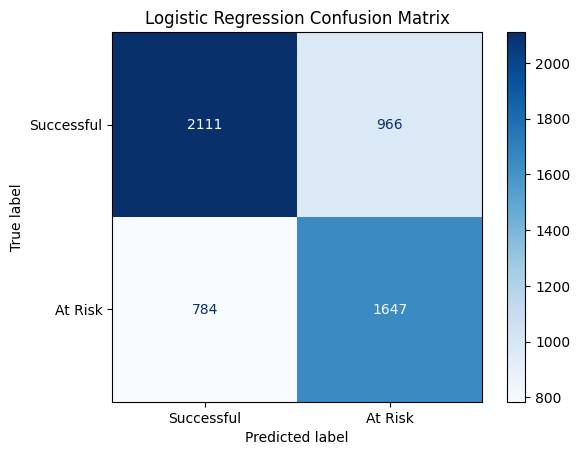

              precision    recall  f1-score   support

  Successful       0.73      0.69      0.71      3077
     At Risk       0.63      0.68      0.65      2431

    accuracy                           0.68      5508
   macro avg       0.68      0.68      0.68      5508
weighted avg       0.69      0.68      0.68      5508



In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

best_model = fitted_models["Logistic Regression"]
best_predictions = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    display_labels=["Successful", "At Risk"],
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Successful", "At Risk"]
    )
)

In [19]:
import numpy as np

ensemble_model_names = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting"
]

# Average the probability predictions from the three models
ensemble_probabilities = np.mean(
    [
        fitted_models[name].predict_proba(X_test)[:, 1]
        for name in ensemble_model_names
    ],
    axis=0
)

ensemble_predictions = (ensemble_probabilities >= 0.5).astype(int)

ensemble_result = pd.DataFrame([{
    "Model": "Soft Voting Ensemble",
    "Accuracy": accuracy_score(y_test, ensemble_predictions),
    "Balanced Accuracy": balanced_accuracy_score(
        y_test, ensemble_predictions
    ),
    "Precision": precision_score(y_test, ensemble_predictions),
    "Recall": recall_score(y_test, ensemble_predictions),
    "F1": f1_score(y_test, ensemble_predictions),
    "ROC-AUC": roc_auc_score(y_test, ensemble_probabilities)
}])

final_results = (
    pd.concat([model_results, ensemble_result], ignore_index=True)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(final_results.round(3))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.682,0.682,0.630,0.677,0.653,0.745
1,Soft Voting Ensemble,0.685,0.681,0.640,0.652,0.646,0.749
2,Gradient Boosting,0.686,0.682,0.644,0.647,0.645,0.746
3,Random Forest,0.681,0.675,0.644,0.619,0.632,0.740
4,Decision Tree,0.653,0.652,0.599,0.645,0.621,0.708
5,Dummy Baseline,0.559,0.500,0.000,0.000,0.000,0.500


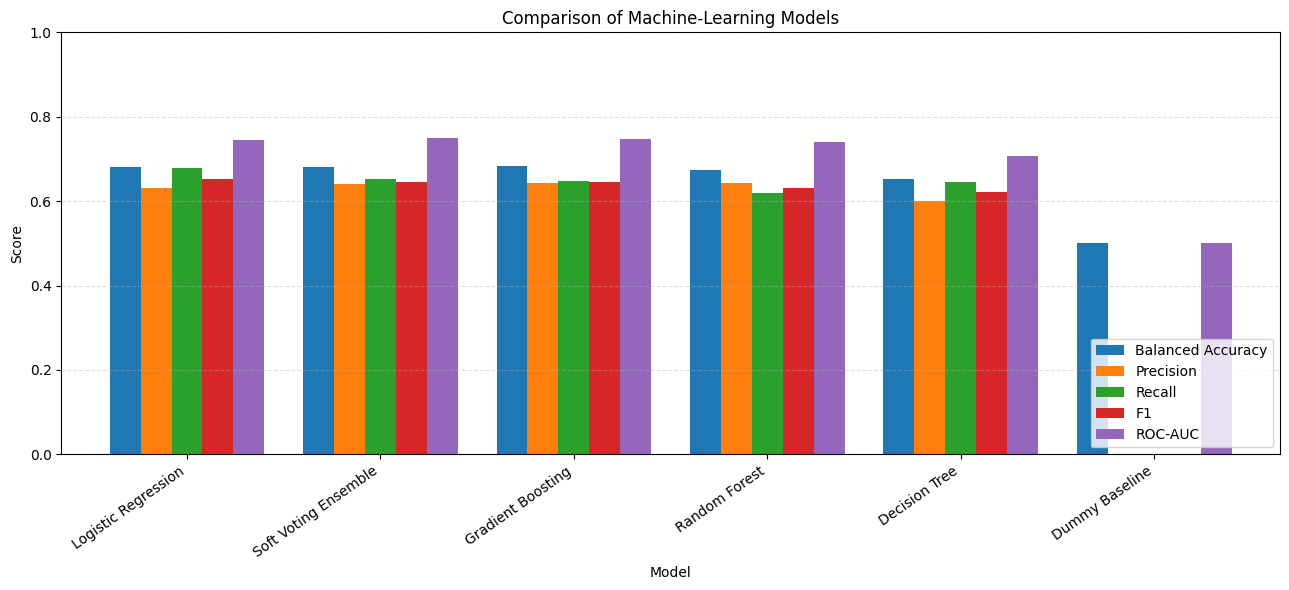

In [20]:
import matplotlib.pyplot as plt

metrics_to_plot = [
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

comparison_plot = final_results.set_index("Model")[metrics_to_plot]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(13, 6),
    width=0.8
)

plt.title("Comparison of Machine-Learning Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
# Profile features without early VLE engagement
profile_categorical_features = categorical_features

profile_numeric_features = [
    "num_of_prev_attempts",
    "studied_credits"
]

profile_features = (
    profile_categorical_features + profile_numeric_features
)

X_profile = model_data[profile_features]

# Use exactly the same students from the existing train/test split
X_profile_train = X_profile.loc[X_train.index]
X_profile_test = X_profile.loc[X_test.index]

profile_preprocessor = ColumnTransformer([
    (
        "categorical",
        categorical_pipeline,
        profile_categorical_features
    ),
    (
        "numeric",
        numeric_pipeline,
        profile_numeric_features
    )
])

profile_model = Pipeline([
    ("preprocessor", profile_preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

profile_model.fit(X_profile_train, y_train)

profile_predictions = profile_model.predict(X_profile_test)
profile_probabilities = profile_model.predict_proba(
    X_profile_test
)[:, 1]

full_predictions = fitted_models[
    "Logistic Regression"
].predict(X_test)

full_probabilities = fitted_models[
    "Logistic Regression"
].predict_proba(X_test)[:, 1]

ablation_results = pd.DataFrame([
    {
        "Feature Set": "Student Profile Only",
        "Balanced Accuracy": balanced_accuracy_score(
            y_test, profile_predictions
        ),
        "Precision": precision_score(
            y_test, profile_predictions
        ),
        "Recall": recall_score(
            y_test, profile_predictions
        ),
        "F1": f1_score(
            y_test, profile_predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_test, profile_probabilities
        )
    },
    {
        "Feature Set": "Profile + Weeks 1–4 Engagement",
        "Balanced Accuracy": balanced_accuracy_score(
            y_test, full_predictions
        ),
        "Precision": precision_score(
            y_test, full_predictions
        ),
        "Recall": recall_score(
            y_test, full_predictions
        ),
        "F1": f1_score(
            y_test, full_predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_test, full_probabilities
        )
    }
])

display(ablation_results.round(3))

,Feature Set,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Student Profile Only,0.618,0.564,0.610,0.586,0.663
1,Profile + Weeks 1–4 Engagement,0.682,0.630,0.677,0.653,0.745


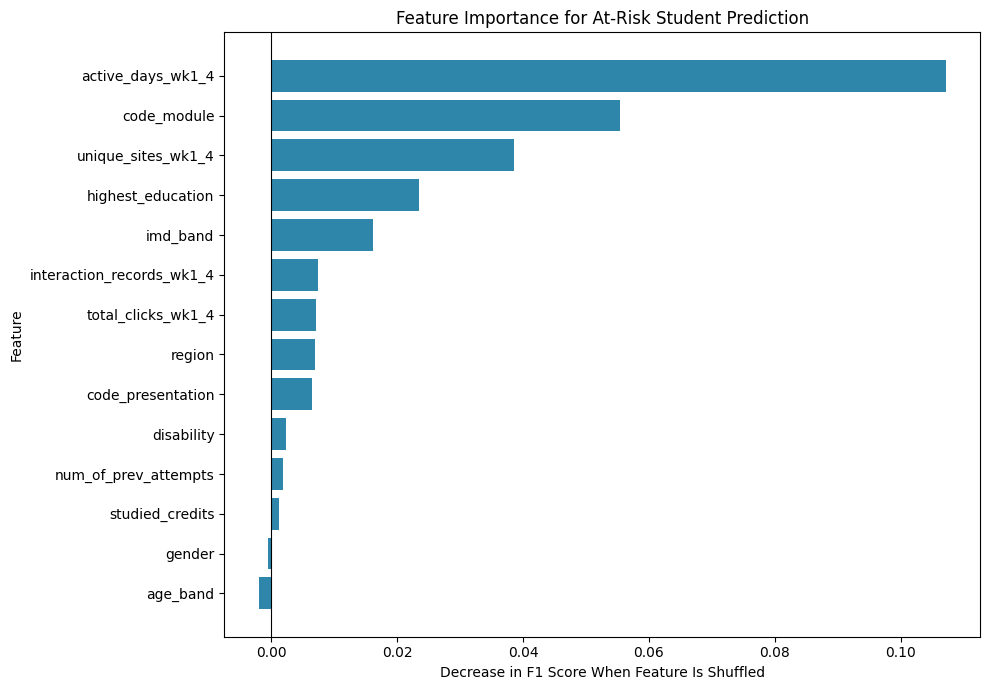

,Feature,Importance
12,active_days_wk1_4,0.1071
0,code_module,0.0555
13,unique_sites_wk1_4,0.0385
4,highest_education,0.0234
5,imd_band,0.0161
11,interaction_records_wk1_4,0.0074
10,total_clicks_wk1_4,0.0071
3,region,0.0069
1,code_presentation,0.0064
7,disability,0.0023


In [22]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

importance_result = permutation_importance(
    fitted_models["Logistic Regression"],
    X_test,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance_result.importances_mean
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color="#2E86AB"
)

plt.title("Feature Importance for At-Risk Student Prediction")
plt.xlabel("Decrease in F1 Score When Feature Is Shuffled")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

display(
    importance_df.sort_values(
        "Importance",
        ascending=False
    ).round(4)
)